<a href="https://colab.research.google.com/github/shina227/API-weather-webapp/blob/main/Malaria_Diagnosis_CNN_Group6_EvenNumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [3]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [4]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [5]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [6]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-10-03 12:41:50--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 99.86.101.114, 99.86.101.69, 99.86.101.109, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|99.86.101.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   377MB/s    in 0.9s    

2026-10-03 12:41:51 (377 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


# Set-up

In [7]:
# Verify dataset structure and per-class image counts
from pathlib import Path

root = Path("cell_images")
print("Contents:", sorted(p.name for p in root.iterdir()))

for cls in ("Parasitized", "Uninfected"):
    n = len(list((root / cls).glob("*.png")))
    print(f"{cls:12s} {n}")

Contents: ['Parasitized', 'Uninfected']
Parasitized  13779
Uninfected   13779


In [8]:
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

# --- Config (must match the group's conventions) ---
SEED = 42
DATA_DIR = Path("cell_images")
SHARED_DIR = Path("/content/drive/MyDrive/ml-formative-2")  # edit to your shared folder
SPLIT_PATH = SHARED_DIR / "split.json"
CLASS_TO_LABEL = {"Uninfected": 0, "Parasitized": 1}  # 1 = Parasitized


def build_split() -> dict:
    """Stratified 80/10/10 split of relative image paths."""
    paths, labels = [], []
    for cls, label in CLASS_TO_LABEL.items():
        files = sorted((DATA_DIR / cls).glob("*.png"))  # sorted -> deterministic
        paths += [f"{cls}/{f.name}" for f in files]
        labels += [label] * len(files)

    # 80% train, then split the remaining 20% evenly into val and test
    p_train, p_rest, y_train, y_rest = train_test_split(
        paths, labels, test_size=0.2, stratify=labels, random_state=SEED)
    p_val, p_test, y_val, y_test = train_test_split(
        p_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)

    return {
        "train": {"paths": p_train, "labels": y_train},
        "val": {"paths": p_val, "labels": y_val},
        "test": {"paths": p_test, "labels": y_test},
    }


SHARED_DIR.mkdir(parents=True, exist_ok=True)
if SPLIT_PATH.exists():
    print("Loading existing split:", SPLIT_PATH)
else:
    SPLIT_PATH.write_text(json.dumps(build_split()))
    print("Created new split:", SPLIT_PATH)

split = json.loads(SPLIT_PATH.read_text())
for name, d in split.items():
    n_pos = sum(d["labels"])
    print(f"{name:5s} n={len(d['labels']):6d}  parasitized={n_pos} ({n_pos / len(d['labels']):.1%})")

Created new split: /content/drive/MyDrive/ml-formative-2/split.json
train n= 22046  parasitized=11023 (50.0%)
val   n=  2756  parasitized=1378 (50.0%)
test  n=  2756  parasitized=1378 (50.0%)


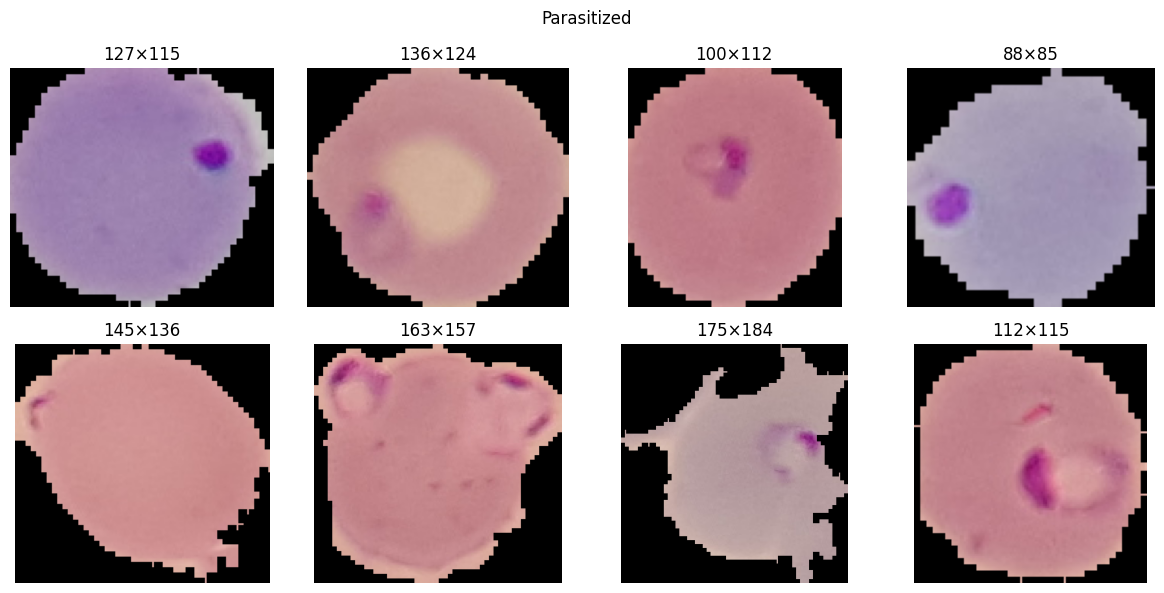

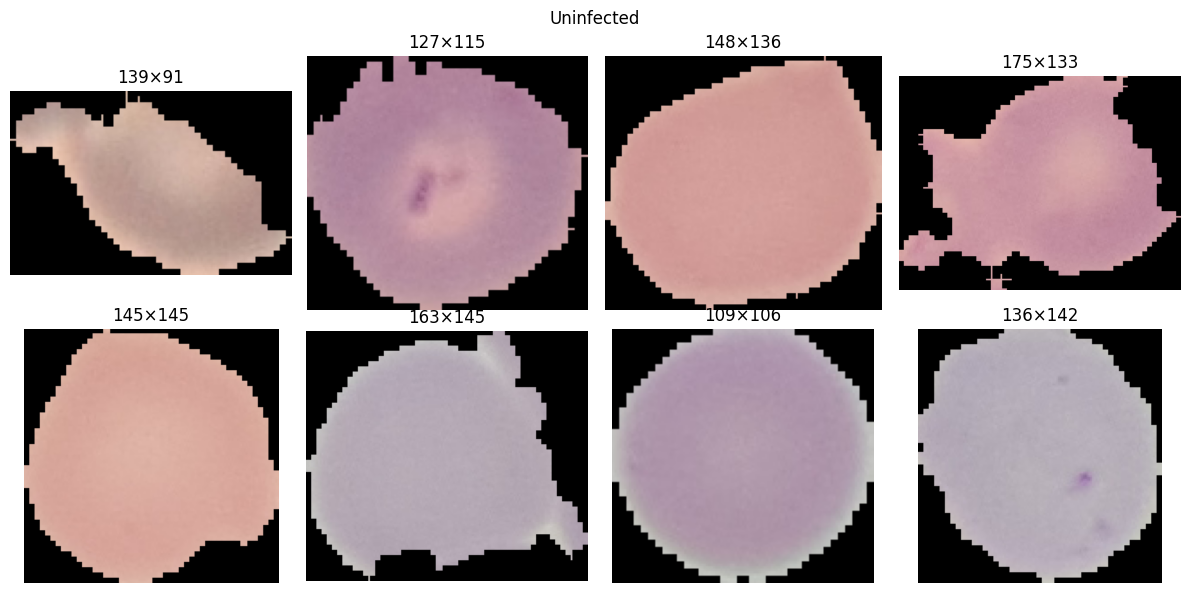

In [9]:
import random
import matplotlib.pyplot as plt
from matplotlib.image import imread

def show_samples(cls: str, n: int = 8, seed: int = 42) -> None:
    """Plot n random images of a class, titled with raw width×height."""
    files = random.Random(seed).sample(list((DATA_DIR / cls).glob("*.png")), n)
    fig, axes = plt.subplots(2, n // 2, figsize=(12, 6))
    for ax, f in zip(axes.ravel(), files):
        img = imread(f)
        ax.imshow(img)
        ax.set_title(f"{img.shape[1]}×{img.shape[0]}")
        ax.axis("off")
    fig.suptitle(cls)
    plt.tight_layout()
    plt.show()

show_samples("Parasitized")
show_samples("Uninfected")

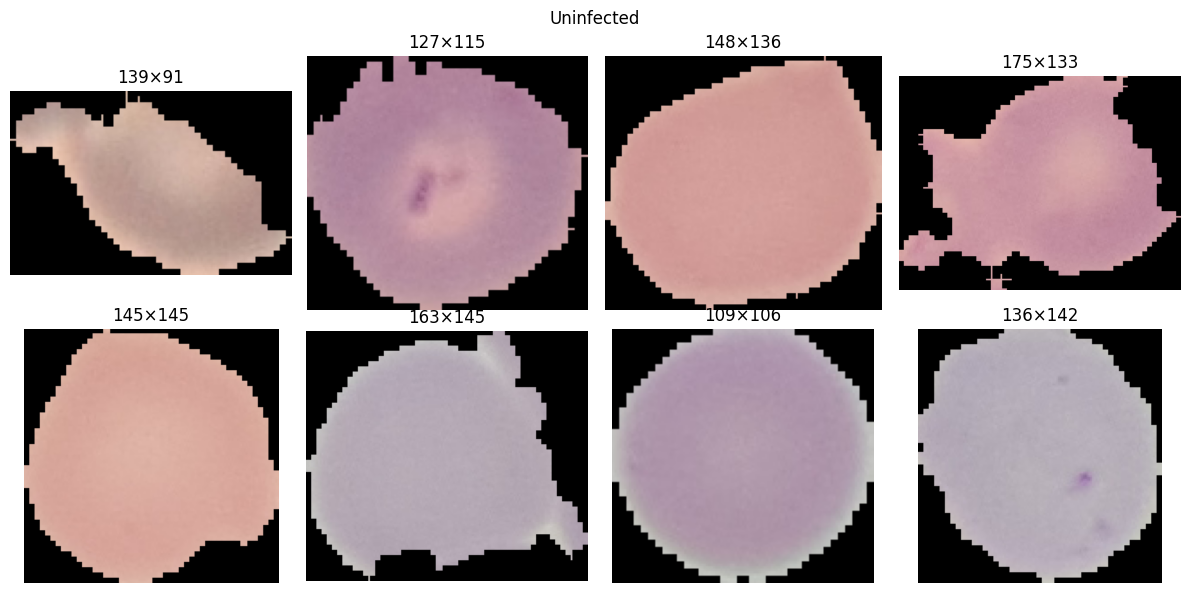

In [10]:
show_samples("Uninfected")

data pipeline

In [11]:
import numpy as np
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(name: str, shuffle: bool = False) -> tf.data.Dataset:
    """tf.data pipeline: decode -> resize -> [0,1]. No augmentation (an experiment variable)."""
    paths = [str(DATA_DIR / p) for p in split[name]["paths"]]
    labels = np.array(split[name]["labels"], dtype="float32")

    def load(path, label):
        img = tf.io.decode_png(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0  # float32 in [0, 1]
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:  # full shuffle of filenames is cheap (strings only)
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(load, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset("train", shuffle=True)
val_ds = make_dataset("val")
test_ds = make_dataset("test")  # never shuffled: keeps order for error analysis and Grad-CAM

# Sanity check one batch
x, y = next(iter(train_ds))
print(x.shape, x.dtype, float(tf.reduce_min(x)), float(tf.reduce_max(x)), y[:8].numpy())

(32, 128, 128, 3) <dtype: 'float32'> 0.0 0.9281709790229797 [0. 0. 1. 1. 1. 1. 1. 0.]


Builder

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

keras.utils.set_random_seed(42)  # reproducible init (matches the split seed)


def build_plain_cnn(
    input_shape=(128, 128, 3),
    filters=(32, 64, 128, 256),
    convs_per_block=1,       # 1 = baseline, 2 = deeper blocks
    batch_norm=False,
    head="flatten",          # "flatten" | "gap"
    dense_units=128,
    dropout=0.0,             # applied in the head only
    l2=0.0,                  # weight decay on conv + dense kernels
    name="plain_cnn",
) -> keras.Model:
    """VGG-style plain CNN: [Conv3x3 -> (BN) -> ReLU] x n -> MaxPool, repeated; no skip connections."""
    reg = regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=input_shape))

    for b, f in enumerate(filters, start=1):
        for i in range(1, convs_per_block + 1):
            model.add(layers.Conv2D(
                f, 3, padding="same", kernel_initializer="he_normal",
                kernel_regularizer=reg,
                use_bias=not batch_norm,          # bias is redundant before BN
                name=f"block{b}_conv{i}"))
            if batch_norm:
                model.add(layers.BatchNormalization(name=f"block{b}_bn{i}"))
            model.add(layers.ReLU(name=f"block{b}_relu{i}"))
        model.add(layers.MaxPooling2D(2, name=f"block{b}_pool"))

    # Classifier head
    if head == "gap":
        model.add(layers.GlobalAveragePooling2D(name="gap"))
    elif head == "flatten":
        model.add(layers.Flatten(name="flatten"))
    else:
        raise ValueError(f"Unknown head: {head!r}")

    model.add(layers.Dense(dense_units, activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=reg, name="fc"))
    if dropout > 0:
        model.add(layers.Dropout(dropout, name="dropout"))
    model.add(layers.Dense(1, activation="sigmoid", name="output"))  # P(Parasitized)
    return model


def last_conv_name(model: keras.Model) -> str:
    """Grad-CAM target: the activated feature map of the last conv (pre-pool, 16x16)."""
    conv = [l.name for l in model.layers if isinstance(l, layers.Conv2D)][-1]
    return conv.replace("_conv", "_relu")

In [13]:
model = build_plain_cnn()
model.summary()

# 1) Parameter count must match the design table
assert model.count_params() == 2_485_825, model.count_params()

# 2) Output shape and range on a dummy batch
out = model(tf.random.uniform((4, 128, 128, 3)))
assert out.shape == (4, 1) and bool(tf.reduce_all((out > 0) & (out < 1)))

# 3) Grad-CAM target exists and is 16x16 spatial
target = model.get_layer(last_conv_name(model))
print("Grad-CAM layer:", target.name, target.output.shape)

# 4) Deeper variant builds (target-shape check)
deep = build_plain_cnn(convs_per_block=2, batch_norm=True, head="gap", dropout=0.5)
print(f"Deep variant params: {deep.count_params():,}")

Model: "plain_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu1 (ReLU)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

Grad-CAM layer: block4_relu1 (None, 16, 16, 256)
Deep variant params: 1,208,161


In [14]:
def compile_model(model: keras.Model, lr: float = 1e-3) -> keras.Model:
    """Shared compile step so every experiment uses identical metrics."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),   # recall of class 1 = sensitivity
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


model = compile_model(build_plain_cnn(), lr=1e-3)
history = model.fit(train_ds, validation_data=val_ds, epochs=1)  # sanity run only

689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.7883 - auc: 0.8939 - loss: 0.4261 - precision: 0.8050 - recall: 0.7609 - val_accuracy: 0.9470 - val_auc: 0.9830 - val_loss: 0.1638 - val_precision: 0.9681 - val_recall: 0.9245


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score


def evaluate_model(model: keras.Model, ds, threshold: float = 0.5) -> dict:
    """Return the full metric set (label 1 = Parasitized).

    Labels and predictions are collected in a single pass so they stay aligned
    even if the dataset reshuffles. Use val_ds during development; test_ds only once, at the end.
    """
    y_true, y_prob = [], []
    for x, y in ds:
        y_prob.append(model.predict_on_batch(x).ravel())
        y_true.append(y.numpy().ravel())
    y_true, y_prob = np.concatenate(y_true), np.concatenate(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)          # recall of Parasitized
    return {
        "accuracy": (tp + tn) / len(y_true),
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": tn / (tn + fp),
        "f1": 2 * precision * sensitivity / (precision + sensitivity),
        "auc": roc_auc_score(y_true, y_prob),
        "confusion": np.array([[tn, fp], [fn, tp]]),
        "y_true": y_true,
        "y_prob": y_prob,   # kept for ROC curve and error analysis later
    }


# Quick test on the sanity model (VALIDATION set, not test)
res = evaluate_model(model, val_ds)
print({k: round(float(v), 4) for k, v in res.items() if np.ndim(v) == 0})
print(res["confusion"])

{'accuracy': 0.947, 'precision': 0.9681, 'sensitivity': 0.9245, 'specificity': 0.9695, 'f1': 0.9458, 'auc': 0.9845}
[[1336   42]
 [ 104 1274]]


In [16]:
import json
from pathlib import Path

import pandas as pd
from tensorboard.plugins.hparams import api as hp

ROOT = Path("/content/drive/MyDrive/ml-formative-2/model4")   # shared Drive folder
LOG_DIR, MODEL_DIR = ROOT / "logs", ROOT / "models"
RESULTS_CSV = ROOT / "results.csv"
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 25, 5, 32   # same budget for every run = fair comparison


def run_experiment(name, change, model_kwargs, train_ds, val_ds,
                   lr=1e-3, augmentation="none", seed=42) -> dict:
    """Train one experiment end to end.

    name   e.g. 'plain_cnn_exp_01_baseline' (TensorBoard run name)
    change one-line description of what differs from the previous config
    """
    keras.utils.set_random_seed(seed)                  # identical init across runs
    for d in (LOG_DIR / name, MODEL_DIR):
        d.mkdir(parents=True, exist_ok=True)
    model_path = MODEL_DIR / f"{name}.keras"

    model = compile_model(build_plain_cnn(name=name, **model_kwargs), lr=lr)
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=MAX_EPOCHS,
        callbacks=[
            keras.callbacks.TensorBoard(log_dir=str(LOG_DIR / name)),
            keras.callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                          restore_best_weights=True),
        ],
    )

    # Metrics of the best (restored) weights on the VALIDATION set
    res = evaluate_model(model, val_ds)
    scalars = {k: float(res[k]) for k in
               ("accuracy", "precision", "sensitivity", "specificity", "f1", "auc")}
    epochs_run = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    # Required hparams (§4.2) -> TensorBoard HParams table
    hparams = {
        "architecture": (f"plain_{len(model_kwargs.get('filters', (0,)*4))}blk"
                         f"_c{model_kwargs.get('convs_per_block', 1)}"
                         f"_{'bn' if model_kwargs.get('batch_norm') else 'nobn'}"
                         f"_{model_kwargs.get('head', 'flatten')}"),
        "learning_rate": lr, "optimizer": "adam", "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS, "epochs_run": epochs_run,
        "augmentation": augmentation,
        "dropout": float(model_kwargs.get("dropout", 0.0)),
        "l2": float(model_kwargs.get("l2", 0.0)),
    }
    with tf.summary.create_file_writer(str(LOG_DIR / name)).as_default():
        hp.hparams(hparams)
        for k, v in scalars.items():
            tf.summary.scalar(f"final_{k}", v, step=1)

    # One row per run -> Day 2 comparison table
    row = {"run": name, "change": change, **hparams, "best_epoch": best_epoch,
           "params": model.count_params(), **scalars}
    pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", index=False,
                               header=not RESULTS_CSV.exists())
    (LOG_DIR / name / "history.json").write_text(json.dumps(history.history))
    return {**row, "model": model, "history": history, "eval": res}


# Smoke test: 1-epoch plumbing check (delete its folder/row afterwards)
MAX_EPOCHS = 1
smoke = run_experiment("plain_cnn_smoke_test", "smoke test", {}, train_ds, val_ds)
MAX_EPOCHS = 25

689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.8396 - auc: 0.9315 - loss: 0.3565 - precision: 0.8542 - recall: 0.8188 - val_accuracy: 0.9510 - val_auc: 0.9884 - val_loss: 0.1338 - val_precision: 0.9560 - val_recall: 0.9456


Experiment 1

In [19]:
# Experiment 1: baseline, all knobs at their minimal setting
result = run_experiment(
    name="plain_cnn_exp_01_baseline",
    change="baseline: 1 conv/block, no BN, Flatten head, no dropout/L2/augmentation",
    model_kwargs=dict(
        convs_per_block=1,
        batch_norm=False,
        head="flatten",
        dropout=0.0,
        l2=0.0,
    ),
    train_ds=train_ds,
    val_ds=val_ds,
    lr=1e-3,
    augmentation="none",
    seed=42,
)
result

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.8445 - auc: 0.9339 - loss: 0.3367 - precision: 0.8553 - recall: 0.8292 - val_accuracy: 0.9546 - val_auc: 0.9877 - val_loss: 0.1348 - val_precision: 0.9617 - val_recall: 0.9470
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9574 - auc: 0.9871 - loss: 0.1311 - precision: 0.9688 - recall: 0.9453 - val_accuracy: 0.9572 - val_auc: 0.9892 - val_loss: 0.1281 - val_precision: 0.9660 - val_recall: 0.9478
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9599 - auc: 0.9898 - loss: 0.1167 - precision: 0.9681 - recall: 0.9512 - val_accuracy: 0.9615 - val_auc: 0.9883 - val_loss: 0.1269 - val_precision: 0.9670 - val_recall: 0.9557
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9638 - auc: 0.9924 - loss: 0.1032 - precision: 0.9715 - recall: 0.9556 - val_accuracy: 0.9568 - val_auc: 0.9895 - val_loss: 0.1254 - val_precision: 0.9680 - val_recall: 0.9448
Epoch 5/25
689/689 ━━━━━

{'run': 'plain_cnn_exp_01_baseline',
 'change': 'baseline: 1 conv/block, no BN, Flatten head, no dropout/L2/augmentation',
 'architecture': 'plain_4blk_c1_nobn_flatten',
 'learning_rate': 0.001,
 'optimizer': 'adam',
 'batch_size': 32,
 'max_epochs': 25,
 'epochs_run': 9,
 'augmentation': 'none',
 'dropout': 0.0,
 'l2': 0.0,
 'best_epoch': 4,
 'params': 2485825,
 'accuracy': 0.956821480406386,
 'precision': 0.9680297397769517,
 'sensitivity': 0.9448476052249637,
 'specificity': 0.9687953555878084,
 'f1': 0.9562982005141388,
 'auc': 0.9900036021157691,
 'model': <Sequential name=plain_cnn_exp_01_baseline, built=True>,
 'history': <keras.src.callbacks.history.History at 0x7d37e9bc2350>,
 'eval': {'accuracy': np.float64(0.956821480406386),
  'precision': np.float64(0.9680297397769517),
  'sensitivity': np.float64(0.9448476052249637),
  'specificity': np.float64(0.9687953555878084),
  'f1': np.float64(0.9562982005141388),
  'auc': np.float64(0.9900036021157691),
  'confusion': array([[1335

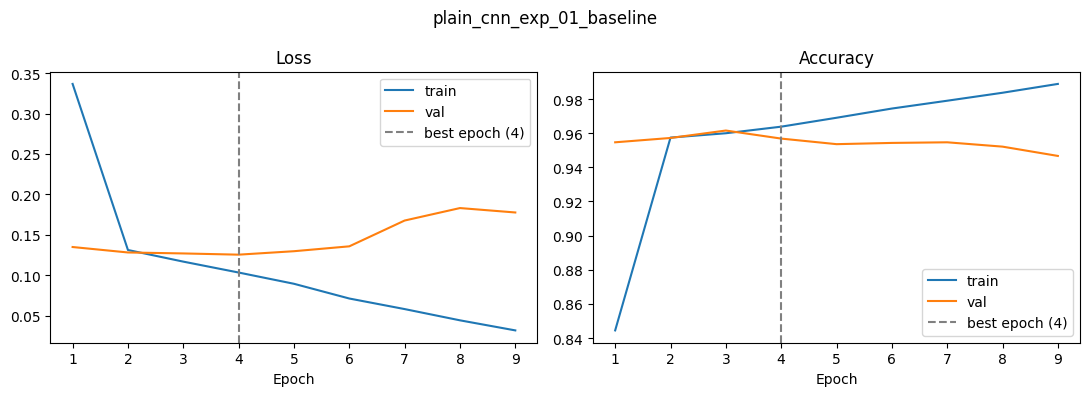

In [20]:
import matplotlib.pyplot as plt

def plot_curves(result: dict) -> None:
    """Plot train/val loss and accuracy; mark the best epoch."""
    h = result["history"].history
    best = result["best_epoch"]  # 1-based, matches the epoch log
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, key, title in zip(axes, ("loss", "accuracy"), ("Loss", "Accuracy")):
        ax.plot(range(1, len(h[key]) + 1), h[key], label="train")
        ax.plot(range(1, len(h[key]) + 1), h[f"val_{key}"], label="val")
        ax.axvline(best, ls="--", c="gray", label=f"best epoch ({best})")
        ax.set(title=title, xlabel="Epoch")
        ax.legend()
    fig.suptitle(result["run"])
    plt.tight_layout()
    plt.show()

plot_curves(result)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.8901 - auc: 0.9422 - loss: 0.4396 - precision: 0.8985 - recall: 0.8797 - val_accuracy: 0.9216 - val_auc: 0.9772 - val_loss: 0.2905 - val_precision: 0.9891 - val_recall: 0.8527
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.9505 - auc: 0.9820 - loss: 0.1630 - precision: 0.9611 - recall: 0.9390 - val_accuracy: 0.9514 - val_auc: 0.9878 - val_loss: 0.1330 - val_precision: 0.9642 - val_recall: 0.9376
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9593 - auc: 0.9885 - loss: 0.1246 - precision: 0.9684 - recall: 0.9496 - val_accuracy: 0.9568 - val_auc: 0.9904 - val_loss: 0.1243 - val_precision: 0.9737 - val_recall: 0.9390
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9613 - auc: 0.9904 - loss: 0.1143 - precision: 0.9696 - recall: 0.9524 - val_accuracy: 0.9543 - val_auc: 0.9904 - val_loss: 0.1301 - val_precision: 0.9750 - val_recall: 0.9325
Epoch 5/25
689/689 ━━━━━

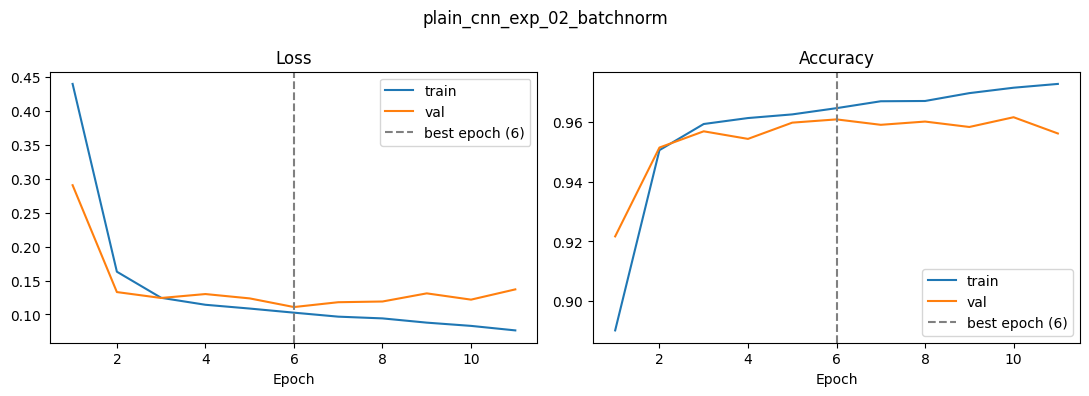

In [21]:
# Experiment 2: add BatchNorm (single change vs exp 01)
result_02 = run_experiment(
    name="plain_cnn_exp_02_batchnorm",
    change="exp 01 + BatchNorm after every conv (Conv→BN→ReLU, no conv bias)",
    model_kwargs=dict(
        convs_per_block=1,
        batch_norm=True,   # only change
        head="flatten",
        dropout=0.0,
        l2=0.0,
    ),
    train_ds=train_ds,
    val_ds=val_ds,
    lr=1e-3,
    augmentation="none",
    seed=42,
)
plot_curves(result_02)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
base = "/content/drive/MyDrive/ml-formative-2/model4"
print(os.listdir(base))  # expect: logs, models, results.csv

import pandas as pd
pd.read_csv(f"{base}/results.csv").tail(3)

Mounted at /content/drive
['logs', 'models', 'results.csv']


,run,change,architecture,learning_rate,optimizer,batch_size,max_epochs,epochs_run,augmentation,dropout,l2,best_epoch,params,accuracy,precision,sensitivity,specificity,f1,auc
0,plain_cnn_exp_01_baseline,"baseline: 1 conv/block, no BN, Flatten head, n...",plain_4blk_c1_nobn_flatten,0.001,adam,32,25,9,none,0.0,0.0,4,2485825,0.956821,0.968030,0.944848,0.968795,0.956298,0.990004
1,plain_cnn_exp_02_batchnorm,exp 01 + BatchNorm after every conv (Conv→BN→R...,plain_4blk_c1_bn_flatten,0.001,adam,32,25,11,none,0.0,0.0,6,2487265,0.960813,0.976012,0.944848,0.976778,0.960177,0.992547


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)
